In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import networkx as nx

import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import p_lithostatic, T_geothermal, MagmaChamber, GlobalSystem, GlobalSystemThreshold

In [2]:
def prop_factory(t_b=1e11, t_d=5e10, K_crust=10e9, G_crust=10e9,
                 K_f=10e9, rho0=2500, mu0=1e6, r_hydr=5):
  return dict(
    t_b = t_b,     # Set Maxwell times
    t_d = t_d,     # Set Maxwell times
    K_crust = K_crust,
    G_crust = G_crust,
    K_f = K_f,
    rho0 = rho0,
    mu0 = mu0,      # Constant viscosity assumption
    r_hydr = r_hydr,     # Effective hydraulic radius
  )

def run_simulation(props):
  t_b = props["t_b"]
  t_d = props["t_d"]
  K_crust = props["K_crust"]
  G_crust = props["G_crust"]
  K_f = props["K_f"]
  rho0 = props["rho0"]
  mu0 = props["mu0"]
  r_hydr = props["r_hydr"]

t_b=1e11
t_d=5e10
K_crust=10e9
G_crust=10e9
K_f=10e9
rho0=2500
mu0=1e6
r_hydr=5

In [3]:
# q0 = global_sys.q0
# L, M, f = global_sys.assemble_global_LMf(q0)

In [4]:

# Build connectivity graph, with large source and sink connectivity values
def compute_eff_conductance(Y, node_list, source_sink_connectivity=1e1,
                            draw_network=False, draw_matrix_spy=False,
                            added_additional_node=False, full_output=False):
    source_connectivity = source_sink_connectivity
    sink_connectivity = source_sink_connectivity

    if added_additional_node:
        # Add edge with infinite conductance for extra (source/sink) nodes
        Y[0,:] = 0.0
        Y[:,0] = 0.0
        Y[-1,:] = 0.0
        Y[:,-1] = 0.0
        # Source connectivity ~infty
        Y[0,1] = source_connectivity
        Y[1,0] = source_connectivity
        Y[-1,-2] = sink_connectivity
        Y[-2,-1] = sink_connectivity

    # Z = np.zeros_like(Y)
    # np.divide(1.0, Y, where=Y != 0, out=Z)

    # Draw undirected graph
    G = nx.Graph(Y)

    if draw_network:
        length_scale = 1.0
        node_size = 200
        nx.draw_networkx(G, pos = {i:(n.x / length_scale, n.z / length_scale,)
                for (i, n) in enumerate(node_list)}, node_size=node_size,# node_color=colors,
        #     edge_cmap=(0, 1)
            )
    
    # Compute Laplacian matrix
    L = nx.laplacian_matrix(G)
    # Compute pseudo inverse naively
    iL = scipy.linalg.pinv(L.todense())

    # Build source-since potential vector
    N = L.shape[0]
    v = np.zeros((N,))
    v[0] = 1.0
    v[-1] = -1.0
    # graph_conductance = 1 / np.einsum("i, i ->", v, scipy.sparse.linalg.spsolve(L, v))
    # graph_conductance = 1
    
    graph_conductance = 1 / np.einsum("i, ij, j ->", v, iL, v)

    # Assemble edge conductances
    edge_conductance = []
    for i in range(Y.shape[0]):
        for j in range(i):
            edge_conductance.append(Y[i,j])

    if draw_matrix_spy:
        fig, ax = plt.subplots(1 ,3, figsize=(11,7))
        ax[0].matshow(Y)
        ax[0].set_title("Y")
        ax[1].matshow(L.todense())
        ax[1].set_title("L")
        ax[2].matshow(iL)
        ax[2].set_title(r"$L^{\dagger}$")

    if full_output:
        return graph_conductance, edge_conductance, Y
    else:
        return graph_conductance


In [5]:
# Network parameters
def make_linear_network(N_chamber, x_scale=10e3, z_scale=40e3,
                        R_min=500, R_max=500,
                        add_source_sink=False) -> GlobalSystemThreshold:
  # Set planar geometry (y-scale = 0)
  y_scale = 0.0
  # Uniformly randomly distribution volume
  V_min = (4/3)*np.pi*R_min**3
  V_max = (4/3)*np.pi*R_max**3
  # List generation of chamber characteristics
  x_nodes = 0.0 * np.random.rand(N_chamber)
  y_nodes = 0.0 * np.random.rand(N_chamber)
  z_nodes = np.linspace(0.0, z_scale, N_chamber)
  V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

  # Force one node at bottom, one at top
  # z_nodes[0] = 0.0
  # z_nodes[-1] = z_scale

  list_nodes = [MagmaChamber(x=x, y=y, z=z,
                       p_setting=None, T_setting=1200, V_setting=V)
    for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]
  
  if add_source_sink:
    # Append virtual source and sink to list_nodes
    z_margin = 2000
    source = MagmaChamber(x=0.0, y=0.0, z=-z_margin,
      p_setting=None, T_setting=1200, V_setting=1e9)
    sink = MagmaChamber(x=0.0, y=0.0, z=z_scale + z_margin,
      p_setting=None, T_setting=1200, V_setting=1e9)
    list_nodes = [source, *list_nodes, sink]

  max_edge_dist = 1.001*np.abs(z_nodes[1] - z_nodes[0])

  # Construct conductivity matrix right here
  Y = np.zeros((N_chamber, N_chamber))

  for i in range(N_chamber):
    node_i = list_nodes[i]
    for j in range(N_chamber):
      if i == j:
        continue
      node_j = list_nodes[j]
      # Compute distance
      dist = np.sqrt((node_i.x - node_j.x) ** 2
                      + (node_i.y - node_j.y) ** 2
                      + (node_i.z - node_j.z) ** 2)
      if np.isclose(dist, 0.0):
        raise ValueError("Distance between chamber {i} and {j} is zero.")
      elif dist > max_edge_dist:
        continue

      # Compute flow admittance ( (m/s) / Pa )
      Y[i,j] = r_hydr * r_hydr / 16.0 / mu0 / dist

  return Y, list_nodes

  # return GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
  #                                   r_hydr=r_hydr, mu0=mu0, 
  #                                   rho0=2500, K_f=K_f, Nr=2, # Nr as small as possible for speed (just want graph)
  #                                   dpdx_crit=0.0,
  #                                   dpdx_threshold_scale=0.0,#1e2,
  #                                   R_outer_ratio=20,
  #                                   max_edge_dist=max_edge_dist)

Conductance of each edge; full-graph network effective conductance (top)


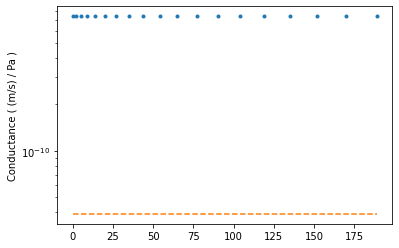

In [6]:
C, E, Y = compute_eff_conductance(*make_linear_network(20), full_output=True)
plt.semilogy(E, '.')
plt.semilogy(np.arange(len(E)), C*np.ones_like(E), '--')
plt.ylabel("Conductance ( (m/s) / Pa )")
print("Conductance of each edge; full-graph network effective conductance (top)")

1D geometry is independent of layout


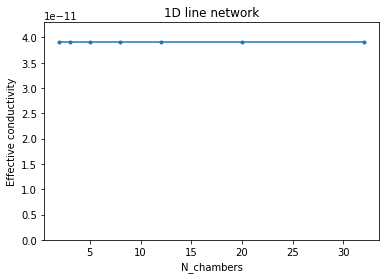

In [7]:
N_range = np.unique(2**np.linspace(1,5,7)).astype(int)
C_out = np.zeros((N_range.size,))
for i, N in enumerate(N_range):
  C_out[i] = compute_eff_conductance(*make_linear_network(N))

plt.plot(N_range, C_out, '.-')
plt.ylim(0, C_out.max() * 1.1)
plt.xlabel("N_chambers")
plt.ylabel("Effective conductivity")
plt.title("1D line network")
print("1D geometry is independent of layout")

In [8]:
# Network parameters
def make_2D_network(N_chamber, x_scale=10e3, z_scale=40e3,
                        R_min=500, R_max=500,
                        add_source_sink=False) -> GlobalSystemThreshold:
  # Set planar geometry (y-scale = 0)
  y_scale = 0.0
  # Uniformly randomly distribution volume
  V_min = (4/3)*np.pi*R_min**3
  V_max = (4/3)*np.pi*R_max**3
  # List generation of chamber characteristics
  x_nodes = x_scale * np.random.rand(N_chamber)
  y_nodes = y_scale * np.random.rand(N_chamber)
  z_nodes = z_scale * np.random.rand(N_chamber)
  V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

  # Force one node at bottom, one at top
  z_nodes[0] = 0.0
  z_nodes[-1] = z_scale
  # Center pinning
  x_nodes[0] = x_scale * 0.5
  x_nodes[-1] = x_scale * 0.5

  list_nodes = [MagmaChamber(x=x, y=y, z=z,
                       p_setting=None, T_setting=1200, V_setting=V)
    for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]
  
  if add_source_sink:
    # Append virtual source and sink to list_nodes
    z_margin = 2000
    source = MagmaChamber(x=0.0, y=0.0, z=-z_margin,
      p_setting=None, T_setting=1200, V_setting=1e9)
    sink = MagmaChamber(x=0.0, y=0.0, z=z_scale + z_margin,
      p_setting=None, T_setting=1200, V_setting=1e9)
    list_nodes = [source, *list_nodes, sink]

  max_edge_dist = 0.1 * z_scale


  # Construct conductivity matrix right here
  Y = np.zeros((N_chamber, N_chamber))

  for i in range(N_chamber):
    node_i = list_nodes[i]
    for j in range(N_chamber):
      if i == j:
        continue
      node_j = list_nodes[j]
      # Compute distance
      dist = np.sqrt((node_i.x - node_j.x) ** 2
                      + (node_i.y - node_j.y) ** 2
                      + (node_i.z - node_j.z) ** 2)
      if np.isclose(dist, 0.0):
        raise ValueError("Distance between chamber {i} and {j} is zero.")
      elif dist > max_edge_dist:
        continue

      # Compute flow admittance ( (m/s) / Pa )
      Y[i,j] = r_hydr * r_hydr / 16.0 / mu0 / dist

  return Y, list_nodes

  # return GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
  #                                   r_hydr=r_hydr, mu0=mu0, 
  #                                   rho0=2500, K_f=K_f, Nr=2, # Nr as small as possible for speed (just want graph)
  #                                   dpdx_crit=0.0,
  #                                   dpdx_threshold_scale=0.0,#1e2,
  #                                   R_outer_ratio=20,
  #                                   max_edge_dist=max_edge_dist)

Conductance of each edge; full-graph network effective conductance (top)


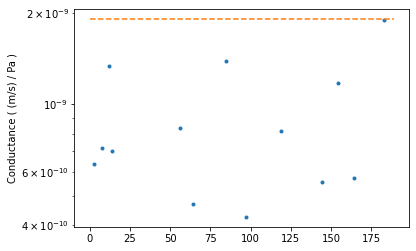

In [9]:
np.random.seed(0)
C, E, Y = compute_eff_conductance(*make_2D_network(20), full_output=True)
plt.semilogy(E, '.')
plt.semilogy(np.arange(len(E)), C*np.ones_like(E), '--')
plt.ylabel("Conductance ( (m/s) / Pa )")
print("Conductance of each edge; full-graph network effective conductance (top)")

In [10]:
''' Ensemble averaging '''
ensemble_size = 20000
N_chamber_2D = 50
ensemble_output = np.zeros((ensemble_size,))

for i in range(ensemble_size):
  ensemble_output[i] = compute_eff_conductance(*make_2D_network(N_chamber_2D), full_output=False)

C:\Users\Fredric\AppData\Local\Temp\ipykernel_31976\748779976.py:47: RuntimeWarning: divide by zero encountered in double_scalars
  graph_conductance = 1 / np.einsum("i, ij, j ->", v, iL, v)


In [11]:
import multiprocessing as mp
network_list = [make_2D_network(N_chamber_2D) for i in range(10)]

In [13]:
# pool = mp.Pool(processes=8)
# map_out = pool.map(lambda network: compute_eff_conductance(network, full_output=False), network_list)

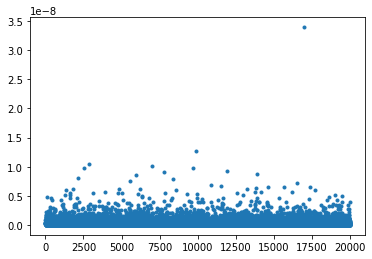

In [14]:
plt.plot(ensemble_output, '.')

In [15]:
# Setting np.inf to true value of 0.0 conductivity (network is not connected)
ensemble_output_filtered = np.where(np.isfinite(ensemble_output),
                                    ensemble_output,
                                    0.0)
# Extract positive values only
ensemble_output_positive = ensemble_output_filtered[np.where(ensemble_output_filtered > 0)]
ensemble_output_filtered.size, ensemble_output_positive.size

(20000, 19971)

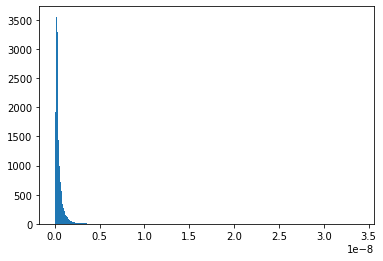

In [16]:
hist_out:tuple = plt.hist(ensemble_output_filtered, bins=400)


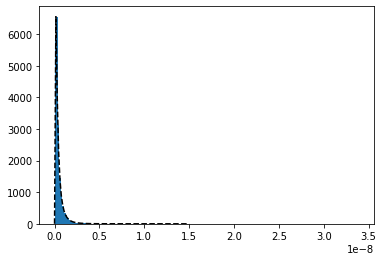

In [17]:
import scipy.stats
fit_params:tuple = scipy.stats.lognorm.fit(ensemble_output_positive)
alpha, loc, scale = fit_params
fit = scipy.stats.lognorm(alpha, loc=loc, scale=scale)

plot_x = np.linspace(0, 1.5e-8, 100)
plot_y = fit.pdf(plot_x)
hist_out:tuple = plt.hist(ensemble_output_positive, bins=200)
plt.plot(plot_x, plot_y/plot_y.max()*hist_out[0].max(), 'k--')

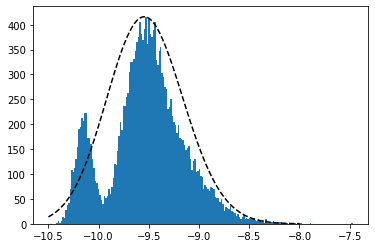

In [18]:
''' Fitting in log '''
ensemble_output_log10 = np.log10(ensemble_output_positive)
fit_params:tuple = scipy.stats.skewnorm.fit(ensemble_output_log10)
a, loc, scale = fit_params
fit = scipy.stats.skewnorm(a, loc=loc, scale=scale)

plot_x = np.linspace(-10.5, -8, 100)
plot_y = fit.pdf(plot_x)
hist_out:tuple = plt.hist(ensemble_output_log10, bins=200)
plt.plot(plot_x, plot_y/plot_y.max()*hist_out[0].max(), 'k--')

In [40]:
def sum_normal_pdf(x, loc1, scale1, amp1, loc2, scale2, amp2, loc3, scale3, amp3):
  ''' Sum of three normals '''
  out = 0.0
  out += amp1 * scipy.stats.norm.pdf(x, loc=loc1 ,scale=scale1)
  out += amp2 * scipy.stats.norm.pdf(x, loc=loc2 ,scale=scale2)
  out += amp3 * scipy.stats.norm.pdf(x, loc=loc3 ,scale=scale3)
  return out


p0= [-10.2, .15, 1, -10.0, .3, 1.0, -9., .1, 1.0]

# p0 = np.array([[-1.01677686e+01,  8.11013479e-02,  4.21135313e+01],
#        [-9.25761019e+00,  3.42200747e-01,  1.35636754e+02],
#        [-9.60303948e+00,  1.78207813e-01,  1.64397188e+02]])

fitted_params, _ = scipy.optimize.curve_fit(
  sum_normal_pdf, 0.5 * (hist_out[1][1:] + hist_out[1][:-1]), hist_out[0], p0=p0)
fitted_params.reshape((3,3))

array([[-1.01495391e+01,  8.44190263e-02,  4.46248511e+01],
       [-9.56137911e+00,  1.80934050e-01,  1.45243412e+02],
       [-9.23464394e+00,  2.98000867e-01,  1.03794053e+02]])

In [48]:
param_table = fitted_params.reshape((3,3))
labels_table = np.array(["Loc        ", "Scale    ", "Amp"])
print(labels_table)
for i in range(param_table.shape[0]):
  print(param_table[i,:])

['Loc        ' 'Scale    ' 'Amp']
[-10.14953914   0.08441903  44.62485109]
[ -9.56137911   0.18093405 145.2434117 ]
[ -9.23464394   0.29800087 103.79405308]


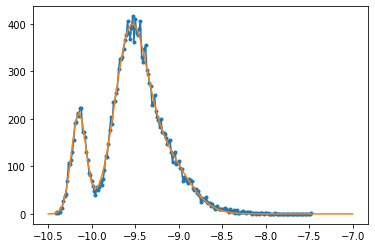

In [41]:
x_range = np.linspace(-10.5, -7.0, 100)
y_range = sum_normal_pdf(x_range, *fitted_params)
plt.plot(0.5 * (hist_out[1][1:] + hist_out[1][:-1]), hist_out[0], '.-')
plt.plot(x_range, y_range)

## NOTE: max_edge_dist = 0.1 * z_scale, and first + last chambers are pinned to 0.5 * x_scale